In [13]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from ITIS_Model_funcs import get_nominal_param,OLS_res,ITIS

In [14]:
param_log,IC = get_nominal_param()
IC = [ 2.0,          0.,          0.14759607,  0.,         13.75484703,  3.13344442, 15.73028492,  1.38649737]

param_titles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

D = '1'         # '1' for ACTH + Cort,
                # '2' for ACTH + Cort + TNF-a
                # '3' for ACTH + Cort + TNF-a + IL10
dpoints = '1'   # '1' for 25, '2' for 13

if D == '1':
    output_ids = [6,7]
elif D == '2':
    output_ids = [3,6,7]
else:
    output_ids = [3,4,6,7]

with open('syntheticData\\TRUE_SOL' + D + dpoints + '.pkl', 'rb') as f:
    results = pickle.load(f)

t_data = results['t_data']
y_data = results['y_data']

##SENSITIVITY ANALYSIS
h = 1e-6  #amount to perturb parameters
n_param = len(param_log)
n_states = len(output_ids)

S = np.zeros((n_param, len(t_data) * n_states)) ##Initialize shape of sensitivity matrix.

for i in range(n_param):  #calculate the relative residual sensitivity to each 45 parameters

        param_in = param_log[i]
        param_delta = param_in + h
##RIGHT NOW THIS IS BEING CALCULATED WITH NOISELESS DATA
        S[i, :] = ((1 / h) * (OLS_res(param_delta, y_data, t_data, i, output_ids, param_log, IC)
                                            - OLS_res(param_in, y_data, t_data, i, output_ids, param_log, IC)))

In [15]:
##import rankings from global analysis
with open('paramRankings\\rankingDesign' + D + '.pkl', 'rb') as f:
    results = pickle.load(f)
rank_value = results['rank_value']      # sorted ranking values
param_sorted_all = results['param_sorted']  #accordingly sorted params as strings
# param_sorted_all[param_sorted_all.index('delta')] = '\u03B4'
# param_sorted_all[param_sorted_all.index('beta')] = '\u03B2'
# param_sorted_all[param_sorted_all.index('eps')] = '\u03B5'
# param_sorted_all[param_sorted_all.index('alpha')] = '\u03B1'


In [16]:
# plt.figure(figsize = (15,6))
# plt.bar(param_sorted_all,rank_value)
# plt.axhline(rank_value[0]*0.25,color='gray', linestyle='--', alpha = .75)
# plt.tight_layout()
# plt.savefig("C:\\Users\\ayres\\Desktop\\ITIS_Repo\\paramRankings\\rankings_Design_" + D + ".png")
# plt.show()

In [17]:

rank_value = results['rank_value']      # sorted ranking values
param_sorted_all = results['param_sorted']  #accordingly sorted params as strings
rank_cut = np.array(rank_value)[np.array(rank_value) > .25 * np.array(rank_value)[0]]
param_sorted = np.array(param_sorted_all)[:len(rank_cut)]
print(param_sorted)


circadian_param = ['alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc'] #exclude?

cond = 0
unid = []
p_indices = [param_titles.index(param_sorted[0])]
for i in range(1,len(rank_cut)):
    p_indices.append(param_titles.index(param_sorted[i]))
    S_opt = S[p_indices,:].copy()
    F_opt = S_opt@S_opt.T
    cond = np.linalg.cond(F_opt)
    if cond > 1e+3:
        unid.append(p_indices.pop())
        print("Removed: ", unid[-1])


S_opt = S[p_indices,:].copy()
F_opt = S_opt@S_opt.T
C_opt = np.linalg.inv(F_opt)
selected = [param_titles[i] for i in p_indices]
print("Design : ", D + dpoints)
print("Number of selected parameters:", len(p_indices))
print("Selected Parameters: ",  selected)
print(p_indices)
print("Excluded Parameters: ", [param_titles[i] for i in unid])
print("Condition Number of F:", np.linalg.cond(F_opt))
print("Diagonals of C:", np.diag(C_opt))

['d7' 'h6' 'd8' 'h11' 'T' 'beta' 'd4' 'k3' 'k14' 'alpha' 'k4' 'h7' 'h4'
 'd6' 'k6']
Removed:  31
Removed:  37
Removed:  8
Removed:  15
Removed:  9
Removed:  28
Design :  11
Number of selected parameters: 9
Selected Parameters:  ['d7', 'h6', 'd8', 'h11', 'T', 'beta', 'd4', 'k3', 'k6']
[33, 12, 36, 32, 43, 39, 16, 7, 14]
Excluded Parameters:  ['k14', 'alpha', 'k4', 'h7', 'h4', 'd6']
Condition Number of F: 995.5990185424665
Diagonals of C: [0.16144243 0.04776797 0.13507541 0.01304562 0.1090241  0.30028879
 0.03104444 0.01443632 0.09035488]


<BarContainer object of 9 artists>

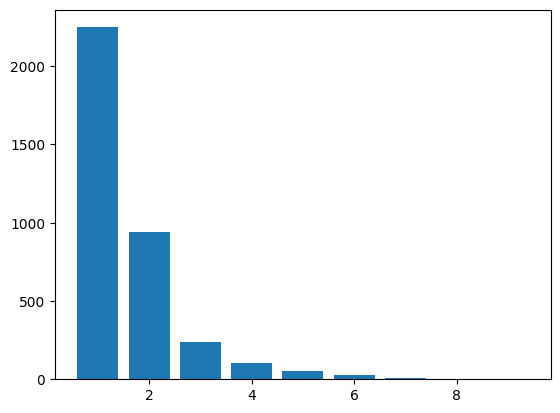

In [18]:
F_eigen = np.linalg.eigvals(F_opt)
plt.figure()
plt.bar(np.linspace(1,len(p_indices),len(p_indices)),F_eigen)


In [19]:
U, S_svd, V = np.linalg.svd(S)
#plt.figure()
#plt.bar(np.linspace(1,len(param_titles),len(param_titles)), S_svd)
p_ind_sv = [param_titles.index(param_sorted_all[i]) for i in range(len(param_titles))]
print(p_ind_sv)
unid_sv = []

for i in range(1,len(param_titles)):
    cond = S_svd[0] / S_svd[-1]
    print(cond)
    print(S_svd)
    if cond > 1e+3:
        unid_sv.append(p_ind_sv.pop())
        print(unid_sv)
        print("Removed: ", unid_sv[-1])
        S_svd = S_svd[:-1]
    else:
        break
print("Saved Param: ", p_ind_sv[:len(S_svd)])
print("Number of saved param: ", len(S_svd))

#implement choosing algorithm using this?

[33, 12, 36, 32, 43, 39, 16, 7, 31, 37, 8, 15, 9, 28, 14, 34, 26, 1, 0, 10, 35, 25, 44, 4, 40, 38, 6, 11, 30, 29, 42, 19, 27, 3, 2, 5, 22, 13, 21, 18, 41, 17, 20, 23, 24]
8907386.953526592
[1.08792728e+02 5.53855217e+01 3.60379795e+01 2.35392348e+01
 1.84005334e+01 1.62810019e+01 1.28316800e+01 1.10851892e+01
 7.72073708e+00 6.95396338e+00 5.64066531e+00 4.62027169e+00
 4.22435121e+00 3.92793576e+00 3.56079133e+00 2.85827081e+00
 2.58565184e+00 2.17291921e+00 1.96656759e+00 1.73542737e+00
 1.61131164e+00 1.38632670e+00 1.21814613e+00 1.09583804e+00
 9.40261029e-01 7.20503646e-01 5.11568238e-01 4.98129571e-01
 3.71759595e-01 2.71508373e-01 2.47502828e-01 2.35244877e-01
 1.19256319e-01 9.25350495e-02 7.12225489e-02 5.06559072e-02
 3.35749264e-02 3.09668229e-02 1.13288986e-02 9.69844300e-03
 2.57881751e-03 8.55678156e-04 2.90053579e-04 5.96051446e-05
 1.22137646e-05]
[24]
Removed:  24
1825223.7840936168
[1.08792728e+02 5.53855217e+01 3.60379795e+01 2.35392348e+01
 1.84005334e+01 1.6281001

In [20]:
#Complete F
F = S@S.T
C = np.linalg.inv(F)
print("Condition Number of F:", np.linalg.cond(F))
print(np.linalg.matrix_rank(F))
print("Diagonals of F:", np.diag(F))
print("Diagonals of C:", np.diag(C))
diag = np.diag(C)
unid = [param_titles[i] for i in list(np.where(diag > 1e+3))[0]]
print("Unidentifiable:", unid) ##this isn't really useful right now

Condition Number of F: 79341054796917.48
45
Diagonals of F: [6.33830152e+00 7.65468967e+01 4.45328873e+01 8.60807895e+02
 8.76742380e+02 7.68857217e+02 1.06111974e+03 6.16393446e+02
 7.16493744e+02 4.01613551e+01 7.93086637e+02 4.38311909e+02
 2.77155370e+02 4.04453592e+01 2.57264886e+01 6.05277316e+02
 6.31849522e+02 5.95999350e+02 3.39044067e+01 5.11695402e+02
 7.21506223e+02 3.72332284e+02 6.23783056e+01 8.78559953e+02
 7.32576946e-04 1.09923739e+02 2.09931399e+01 9.25064135e+02
 8.04915595e+01 9.73112777e+02 9.03115905e+02 6.70385037e+02
 9.80050793e+02 3.81969164e+02 8.73672015e+02 4.99179405e+01
 2.77163862e+02 4.54064848e+01 1.42294716e+00 1.11101046e+02
 4.76484421e+00 8.22779305e+01 1.64551954e+00 3.20750153e+02
 2.09948103e+01]
Diagonals of C: [1.24814028e+05 5.42766622e+04 1.85713585e+06 4.03573334e+02
 5.48562202e+01 4.70749144e+01 4.24859005e+02 7.88647649e+01
 2.70207649e+01 1.31166111e+04 4.52002388e+02 4.70082516e+01
 3.35811354e+03 8.52582800e+04 1.96851350e+04 1.35651

In [21]:
##SAVE FUNCTIONALITY

# all_results = {
#     'S': S,
#     'S_opt': S_opt,
# }
#
# with open('Sensitivities\\sens' + D + dpoints + '.pkl', 'wb') as f:
#     pickle.dump(all_results, f)

In [22]:
##Calculating CIS
from scipy import stats

S2_est = 1e-4
C_ci = S2_est * C_opt
##Retrieve standard errors?
SE = np.sqrt(np.diag(C_ci)) #/ np.sqrt(len(t_data)) ####NOT RIGHT. FIGURE IT OUT AND FIX

##initialize container for bounds
CI = np.zeros((len(param_sorted),2))
alpha = 0.05
t_value = stats.t.ppf(1-alpha, len(t_data))

for i in range(len(param_sorted)):
    CI[i,0] = param_log[p_indices[i]] - t_value * SE[i]
    CI[i,1] = param_log[p_indices[i]] + t_value * SE[i]
    #print(CI[i,0], param_log[p_indices[i]], CI [i,1])
    #print(np.exp(CI[i,0]), np.exp(param_log[p_indices[i]]), np.exp(CI [i,1]))
    print(np.exp(CI[i,0])/np.exp(param_log[p_indices[i]])-1, 0, np.exp(CI [i,1])/np.exp(param_log[p_indices[i]])-1)
##

##HOW DOES LOG SCALE AFFECT OUTCOME?

-0.0068397937091856376 0 0.006886898675421138
-0.0037263325941917502 0 0.0037402700845188264
-0.006258197860914971 0 0.006297609547514016
-0.0019490923947831362 0 0.0019528987749330984
-0.005624200051697392 0 0.005656010586731597
-0.009316702387736298 0 0.009404319634934044
-0.0030051228475242997 0 0.0030141808312065255
-0.002050247732202082 0 0.0020544598839200567
-0.005121356394314991 0 0.005147719701524389


IndexError: list index out of range